# Corporate Greenwashing Accusations: Exploratory Data Analysis

This notebook focuses on four questions:
- How sparse is the company by year panel?
- How coarse is the underlying score lattice behind `GW_SCORE`?
- How do score distributions drift across time?
- Which companies dominate coverage, volatility, and potential holdout structure?

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
from matplotlib.collections import LineCollection
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Rectangle

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

plt.rcParams.update(
    {
        "figure.figsize": (14, 8),
        "figure.dpi": 140,
        "axes.titlesize": 16,
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "font.family": "DejaVu Sans",
    }
)

PALETTE = {
    "paper": "#f7f4ed",
    "panel": "#efe8da",
    "ink": "#1f2a33",
    "muted": "#5c6770",
    "grid": "#c9bfa9",
    "accent": "#b55239",
    "accent2": "#2b7a78",
    "highlight": "#d6a84f",
}

SCORE_CMAP = mcolors.LinearSegmentedColormap.from_list(
    "score_map", ["#113b5c", "#3b7a57", "#d6a84f", "#b55239"]
)
SCORE_CMAP.set_bad(PALETTE["panel"])

DELTA_CMAP = mcolors.LinearSegmentedColormap.from_list(
    "delta_map", [PALETTE["accent"], "#f7f4ed", PALETTE["accent2"]]
)
DELTA_NORM = mcolors.TwoSlopeNorm(vmin=-0.9, vcenter=0.0, vmax=0.9)


def style_axes(ax, title=None, subtitle=None, title_pad=28):
    ax.set_facecolor(PALETTE["panel"])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.grid(axis="y", color=PALETTE["grid"], linewidth=0.9, alpha=0.45)
    ax.tick_params(colors=PALETTE["ink"])
    if title is not None:
        ax.set_title(title, loc="left", color=PALETTE["ink"], pad=title_pad, fontweight="bold")
    if subtitle is not None:
        ax.text(
            0.0,
            1.0,
            subtitle,
            transform=ax.transAxes,
            fontsize=10,
            color=PALETTE["muted"],
            va="bottom",
            ha="left",
        )
    return ax


rng = np.random.default_rng(7)

In [2]:
DATA_PATH = Path("/kaggle/input/datasets/jocelyndumlao/corporate-greenwashing-accusations-dataset/Dataset of “Determinants and forecasting of corpor/Greenwashing_Score_Data.xlsx")

df = (
    pd.read_excel(DATA_PATH)
    .rename(columns=lambda c: str(c).strip())
    .assign(
        COMPANY_NAME=lambda d: d["COMPANY_NAME"].astype(str).str.strip(),
        YEAR=lambda d: d["YEAR"].astype(int),
        GW_SCORE=lambda d: d["GW_SCORE"].astype(float),
        USED_FOR_ANALYSIS=lambda d: d["USED_FOR_ANALYSIS"].astype(bool),
    )
)

years = np.arange(df["YEAR"].min(), df["YEAR"].max() + 1)

score_distribution = (
    df["GW_SCORE"]
    .value_counts()
    .sort_index()
    .rename_axis("score")
    .reset_index(name="count")
)
score_distribution["probability"] = score_distribution["count"] / len(df)

year_summary = (
    df.groupby("YEAR")
    .agg(
        observations=("GW_SCORE", "size"),
        mean_score=("GW_SCORE", "mean"),
        median_score=("GW_SCORE", "median"),
        q10=("GW_SCORE", lambda s: s.quantile(0.10)),
        q25=("GW_SCORE", lambda s: s.quantile(0.25)),
        q75=("GW_SCORE", lambda s: s.quantile(0.75)),
        q90=("GW_SCORE", lambda s: s.quantile(0.90)),
        analysis_share=("USED_FOR_ANALYSIS", "mean"),
    )
    .reindex(years)
)

company_features = (
    df.groupby("COMPANY_NAME")
    .agg(
        observations=("GW_SCORE", "size"),
        first_year=("YEAR", "min"),
        last_year=("YEAR", "max"),
        mean_score=("GW_SCORE", "mean"),
        score_volatility=("GW_SCORE", "std"),
        used_share=("USED_FOR_ANALYSIS", "mean"),
    )
    .assign(
        score_volatility=lambda d: d["score_volatility"].fillna(0.0),
        span=lambda d: d["last_year"] - d["first_year"] + 1,
        window_density=lambda d: d["observations"] / d["span"],
    )
)

panel_density = len(df) / (df["COMPANY_NAME"].nunique() * len(years))
score_entropy_bits = -(score_distribution["probability"] * np.log2(score_distribution["probability"])).sum()
effective_score_states = 2 ** score_entropy_bits

overview = pd.DataFrame(
    {
        "Metric": [
            "Rows",
            "Unique companies",
            "Calendar span",
            "Distinct score states",
            "Panel occupancy",
            "Shannon entropy (bits)",
            "Effective score states",
            "Share used for analysis",
            "Share of companies with a single observation",
        ],
        "Value": [
            f"{len(df):,}",
            f"{df['COMPANY_NAME'].nunique():,}",
            f"{years.min()}-{years.max()} ({len(years)} years)",
            f"{score_distribution.shape[0]}",
            f"{panel_density:.1%}",
            f"{score_entropy_bits:.3f}",
            f"{effective_score_states:.2f}",
            f"{df['USED_FOR_ANALYSIS'].mean():.1%}",
            f"{company_features['observations'].eq(1).mean():.1%}",
        ],
    }
)

display(overview)

display(
    year_summary.style.format(
        {
            "mean_score": "{:.3f}",
            "median_score": "{:.3f}",
            "q10": "{:.3f}",
            "q25": "{:.3f}",
            "q75": "{:.3f}",
            "q90": "{:.3f}",
            "analysis_share": "{:.1%}",
        }
    )
)

display(
    company_features.sort_values(["observations", "mean_score"], ascending=[False, False])
    .head(12)
    .style.format(
        {
            "mean_score": "{:.3f}",
            "score_volatility": "{:.3f}",
            "used_share": "{:.1%}",
            "window_density": "{:.2f}",
        }
    )
)

,Metric,Value
0,Rows,595
1,Unique companies,215
2,Calendar span,2011-2023 (13 years)
3,Distinct score states,22
4,Panel occupancy,21.3%
5,Shannon entropy (bits),3.760
6,Effective score states,13.55
7,Share used for analysis,63.4%
8,Share of companies with a single observation,44.2%


,observations,mean_score,median_score,q10,q25,q75,q90,analysis_share
YEAR,,,,,,,,
2011,17,0.625,0.688,0.225,0.500,0.875,0.900,82.4%
2012,25,0.672,0.750,0.275,0.375,0.938,1.000,84.0%
2013,19,0.639,0.750,0.188,0.354,0.906,1.000,57.9%
2014,18,0.774,0.875,0.312,0.641,1.000,1.000,38.9%
2015,21,0.765,0.812,0.438,0.688,0.875,1.000,71.4%
2016,23,0.747,0.750,0.438,0.594,1.000,1.000,87.0%
2017,32,0.710,0.812,0.256,0.438,0.953,1.000,78.1%
2018,33,0.700,0.750,0.383,0.438,0.875,1.000,75.8%
2019,56,0.636,0.688,0.208,0.438,0.875,0.938,69.6%


,observations,first_year,last_year,mean_score,score_volatility,used_share,span,window_density
COMPANY_NAME,,,,,,,,
RIO TINTO GROUP,13,2011,2023,0.893,0.126,100.0%,13,1.00
SHELL PLC,13,2011,2023,0.822,0.241,76.9%,13,1.00
SYNGENTA AG,12,2011,2022,0.870,0.142,33.3%,12,1.00
BP PLC,12,2011,2023,0.833,0.154,100.0%,13,0.92
NESTLE SA/AG,12,2012,2023,0.807,0.270,66.7%,12,1.00
HENNES & MAURITZ AB,12,2012,2023,0.786,0.235,100.0%,12,1.00
RWE AG,11,2013,2023,0.750,0.288,45.5%,11,1.00
BAYER AG,10,2012,2023,0.702,0.193,60.0%,12,0.83
ANDRITZ AG,10,2011,2022,0.619,0.020,80.0%,12,0.83


## Structural note

`GW_SCORE` is not continuous. It sits on a finite lattice of repeated rational values (mostly sixteenths, with a few thirds and sixths). The first two custom visuals therefore treat score as a discrete state space and use quantile ribbons instead of smoothed density estimates.

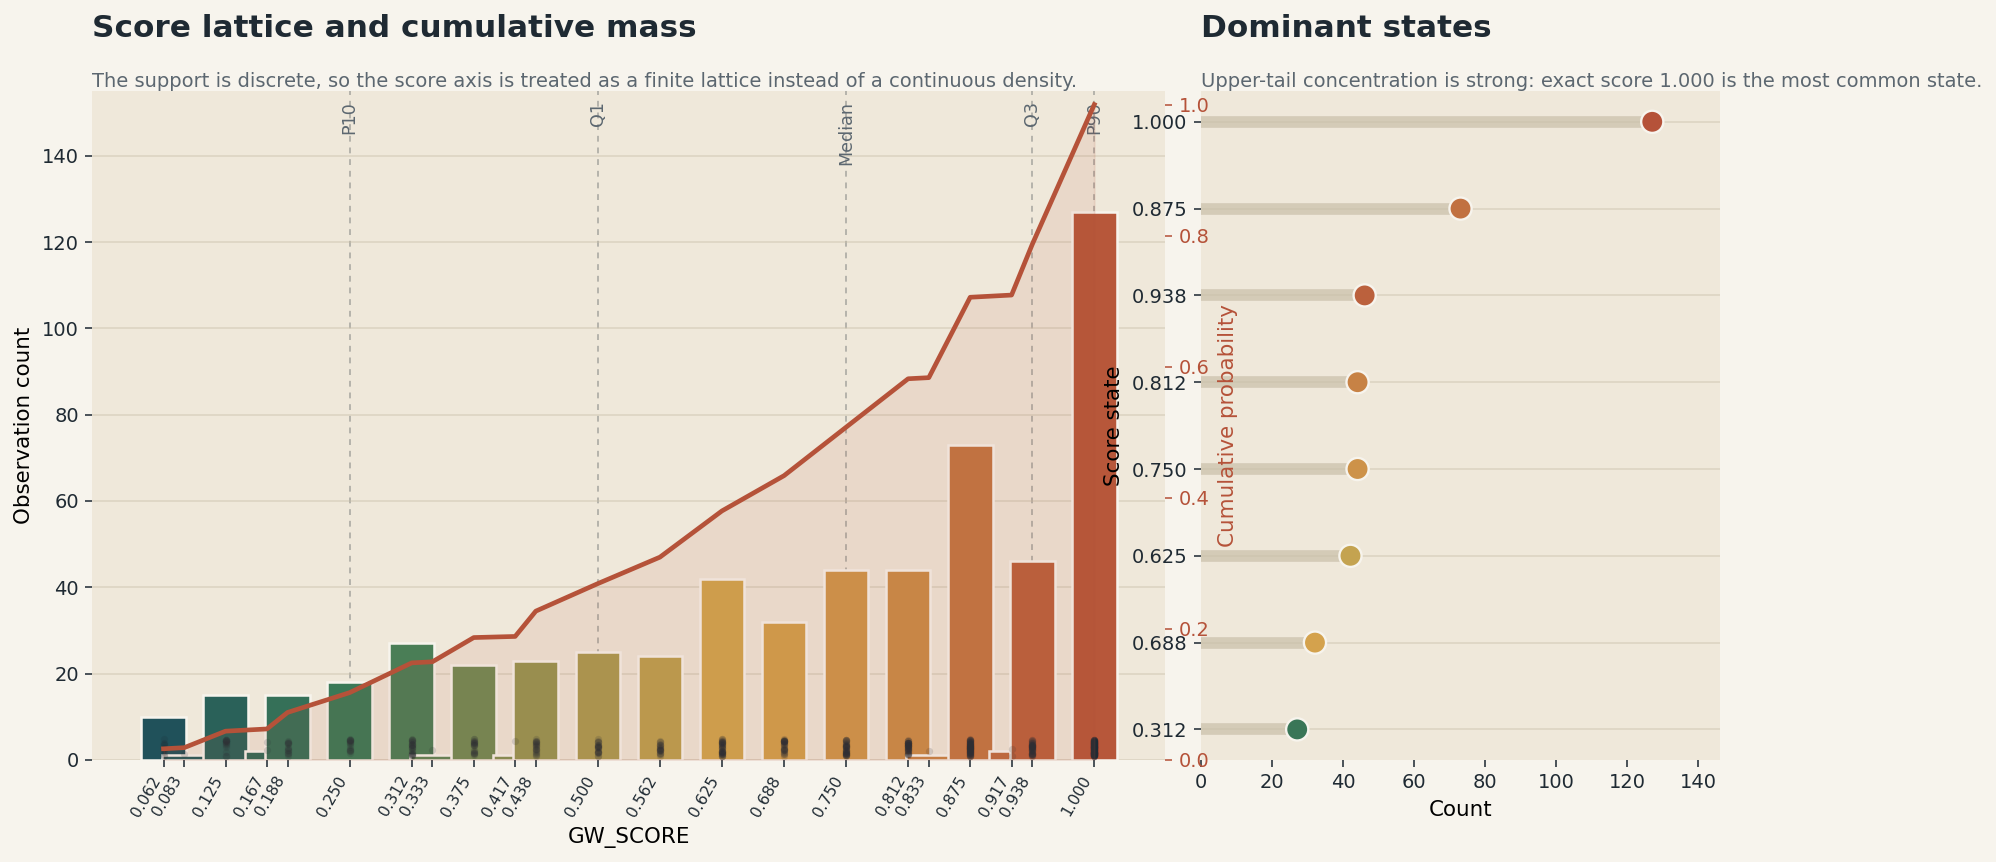

In [3]:
quantiles = df["GW_SCORE"].quantile([0.10, 0.25, 0.50, 0.75, 0.90])
score_positions = score_distribution["score"].to_numpy()
score_counts = score_distribution["count"].to_numpy()
cum_probability = score_distribution["probability"].cumsum().to_numpy()

fig = plt.figure(figsize=(15, 6.2), facecolor=PALETTE["paper"])
gs = GridSpec(1, 12, figure=fig, wspace=0.35)

ax = fig.add_subplot(gs[:, :8])
ax_rank = fig.add_subplot(gs[:, 8:])

style_axes(
    ax,
    "Score lattice and cumulative mass",
    "The support is discrete, so the score axis is treated as a finite lattice instead of a continuous density.",
)
ax.grid(axis="x", visible=False)

bar_colors = SCORE_CMAP(np.linspace(0.12, 0.98, len(score_positions)))
ax.bar(
    score_positions,
    score_counts,
    width=0.045,
    color=bar_colors,
    edgecolor=PALETTE["paper"],
    linewidth=1.3,
    zorder=3,
)

rug_y = rng.uniform(0.8, 4.8, len(df))
ax.scatter(
    df["GW_SCORE"],
    rug_y,
    s=14,
    color=PALETTE["ink"],
    alpha=0.16,
    linewidth=0,
    zorder=4,
)

y_max = score_counts.max() * 1.22
ax.set_ylim(0, y_max)
for q, label in zip(quantiles.values, ["P10", "Q1", "Median", "Q3", "P90"]):
    ax.axvline(q, color=PALETTE["ink"], linestyle=(0, (3, 3)), linewidth=1.0, alpha=0.28, zorder=1)
    ax.text(q, y_max * 0.985, label, rotation=90, va="top", ha="center", fontsize=9, color=PALETTE["muted"])

ax.set_xlabel("GW_SCORE")
ax.set_ylabel("Observation count")
ax.set_xticks(score_positions)
ax.set_xticklabels([f"{x:.3f}" for x in score_positions], rotation=60, ha="right", fontsize=8)

ax_cdf = ax.twinx()
ax_cdf.plot(score_positions, cum_probability, color=PALETTE["accent"], linewidth=2.4, zorder=5)
ax_cdf.fill_between(score_positions, 0, cum_probability, color=PALETTE["accent"], alpha=0.10, zorder=2)
ax_cdf.set_ylim(0, 1.02)
ax_cdf.set_ylabel("Cumulative probability", color=PALETTE["accent"])
ax_cdf.tick_params(axis="y", colors=PALETTE["accent"])
for spine in ax_cdf.spines.values():
    spine.set_visible(False)

style_axes(
    ax_rank,
    "Dominant states",
    "Upper-tail concentration is strong: exact score 1.000 is the most common state.",
)
top_states = score_distribution.sort_values("count", ascending=False).head(8).sort_values("count")
ax_rank.hlines(
    y=np.arange(len(top_states)),
    xmin=0,
    xmax=top_states["count"],
    color=PALETTE["grid"],
    linewidth=6,
    alpha=0.7,
)
ax_rank.scatter(
    top_states["count"],
    np.arange(len(top_states)),
    s=130,
    c=top_states["score"],
    cmap=SCORE_CMAP,
    vmin=0,
    vmax=1,
    edgecolor=PALETTE["paper"],
    linewidth=1.2,
    zorder=3,
)
ax_rank.set_yticks(np.arange(len(top_states)))
ax_rank.set_yticklabels([f"{s:.3f}" for s in top_states["score"]])
ax_rank.set_xlabel("Count")
ax_rank.set_ylabel("Score state")
ax_rank.set_xlim(0, top_states["count"].max() * 1.15)

plt.show()

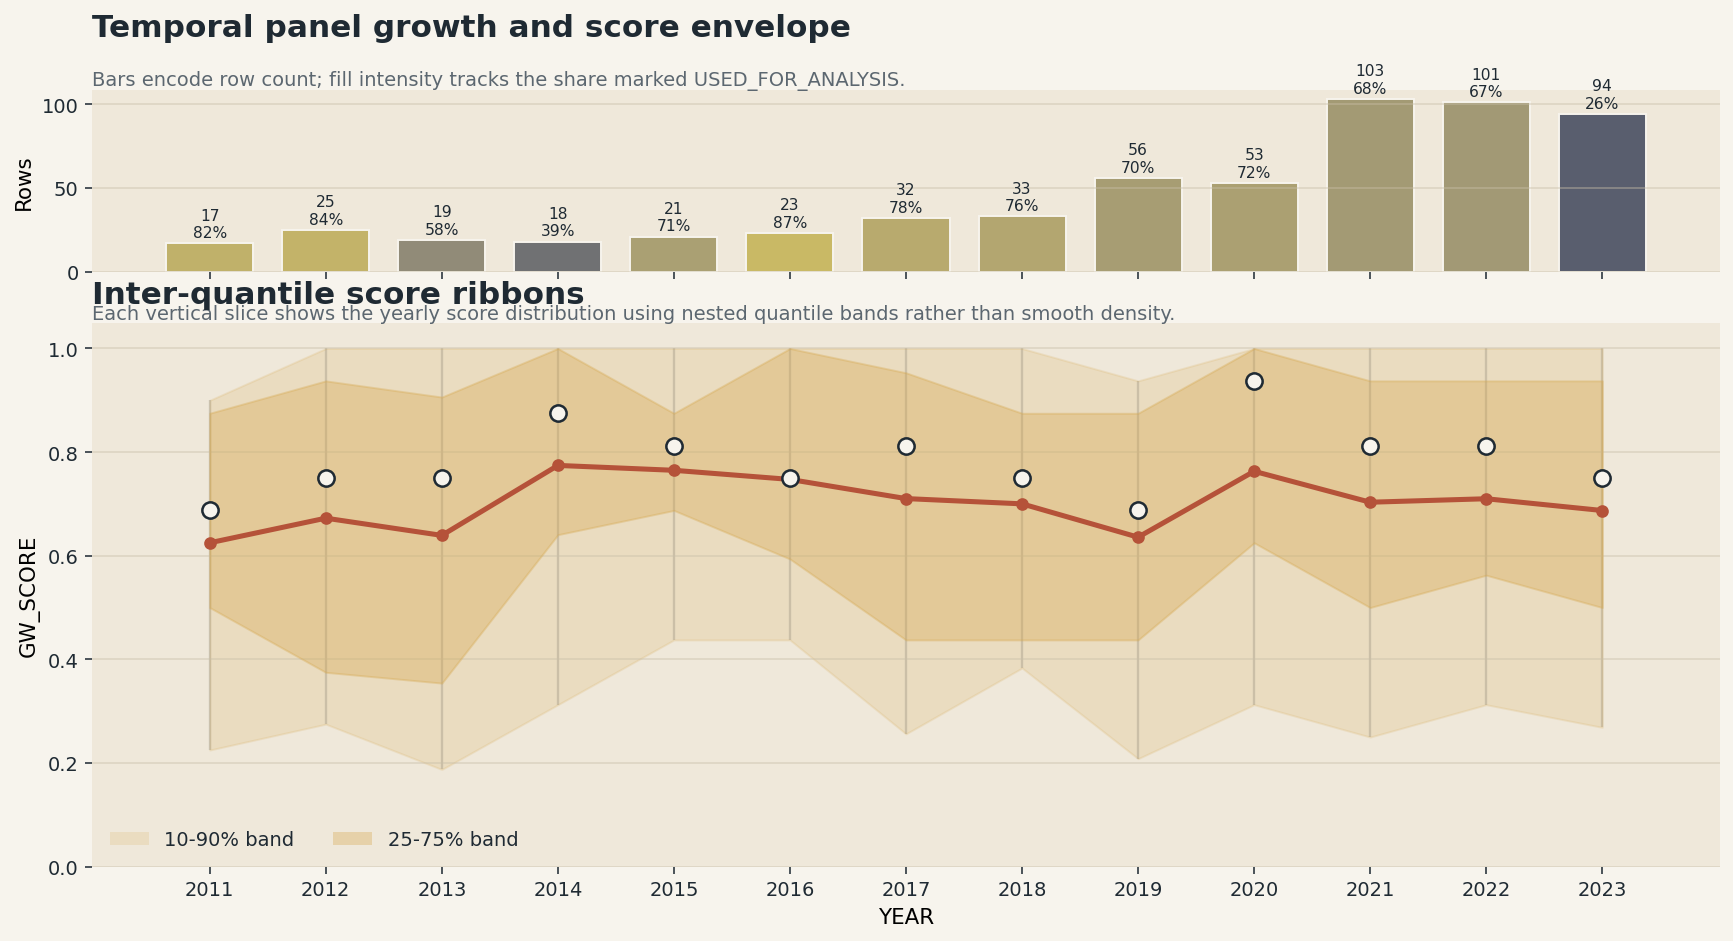

In [4]:
fig = plt.figure(figsize=(15, 7.2), facecolor=PALETTE["paper"])
gs = GridSpec(2, 1, height_ratios=[1.0, 3.0], hspace=0.14, figure=fig)

ax_top = fig.add_subplot(gs[0, 0])
ax = fig.add_subplot(gs[1, 0], sharex=ax_top)

style_axes(
    ax_top,
    "Temporal panel growth and score envelope",
    "Bars encode row count; fill intensity tracks the share marked USED_FOR_ANALYSIS.",
)
ax_top.grid(axis="x", visible=False)

bar_colors = plt.cm.cividis(year_summary["analysis_share"].fillna(0).to_numpy() * 0.75 + 0.15)
ax_top.bar(
    years,
    year_summary["observations"],
    width=0.75,
    color=bar_colors,
    edgecolor=PALETTE["paper"],
    linewidth=1.0,
)
for year, row in year_summary.iterrows():
    ax_top.text(
        year,
        row["observations"] + 2.0,
        f"{int(row['observations'])}\n{row['analysis_share']:.0%}",
        ha="center",
        va="bottom",
        fontsize=8,
        color=PALETTE["ink"],
    )
ax_top.set_ylabel("Rows")
ax_top.tick_params(axis="x", labelbottom=False)

style_axes(
    ax,
    "Inter-quantile score ribbons",
    "Each vertical slice shows the yearly score distribution using nested quantile bands rather than smooth density.",
    title_pad=10,
)
ax.fill_between(years, year_summary["q10"], year_summary["q90"], color=PALETTE["highlight"], alpha=0.18, zorder=1)
ax.fill_between(years, year_summary["q25"], year_summary["q75"], color=PALETTE["highlight"], alpha=0.35, zorder=2)
ax.plot(years, year_summary["mean_score"], color=PALETTE["accent"], linewidth=2.6, marker="o", markersize=5.5, zorder=4)
ax.scatter(years, year_summary["median_score"], s=70, color=PALETTE["paper"], edgecolor=PALETTE["ink"], linewidth=1.3, zorder=5)
for year in years:
    row = year_summary.loc[year]
    ax.vlines(year, row["q10"], row["q90"], color=PALETTE["ink"], alpha=0.18, linewidth=1.2, zorder=0)

ax.set_ylabel("GW_SCORE")
ax.set_xlabel("YEAR")
ax.set_xticks(years)
ax.set_ylim(0, 1.05)

legend_handles = [
    Rectangle((0, 0), 1, 1, facecolor=PALETTE["highlight"], alpha=0.18, edgecolor="none", label="10-90% band"),
    Rectangle((0, 0), 1, 1, facecolor=PALETTE["highlight"], alpha=0.35, edgecolor="none", label="25-75% band"),
]
ax.legend(handles=legend_handles, loc="lower left", frameon=False, ncol=2, labelcolor=PALETTE["ink"])

plt.show()

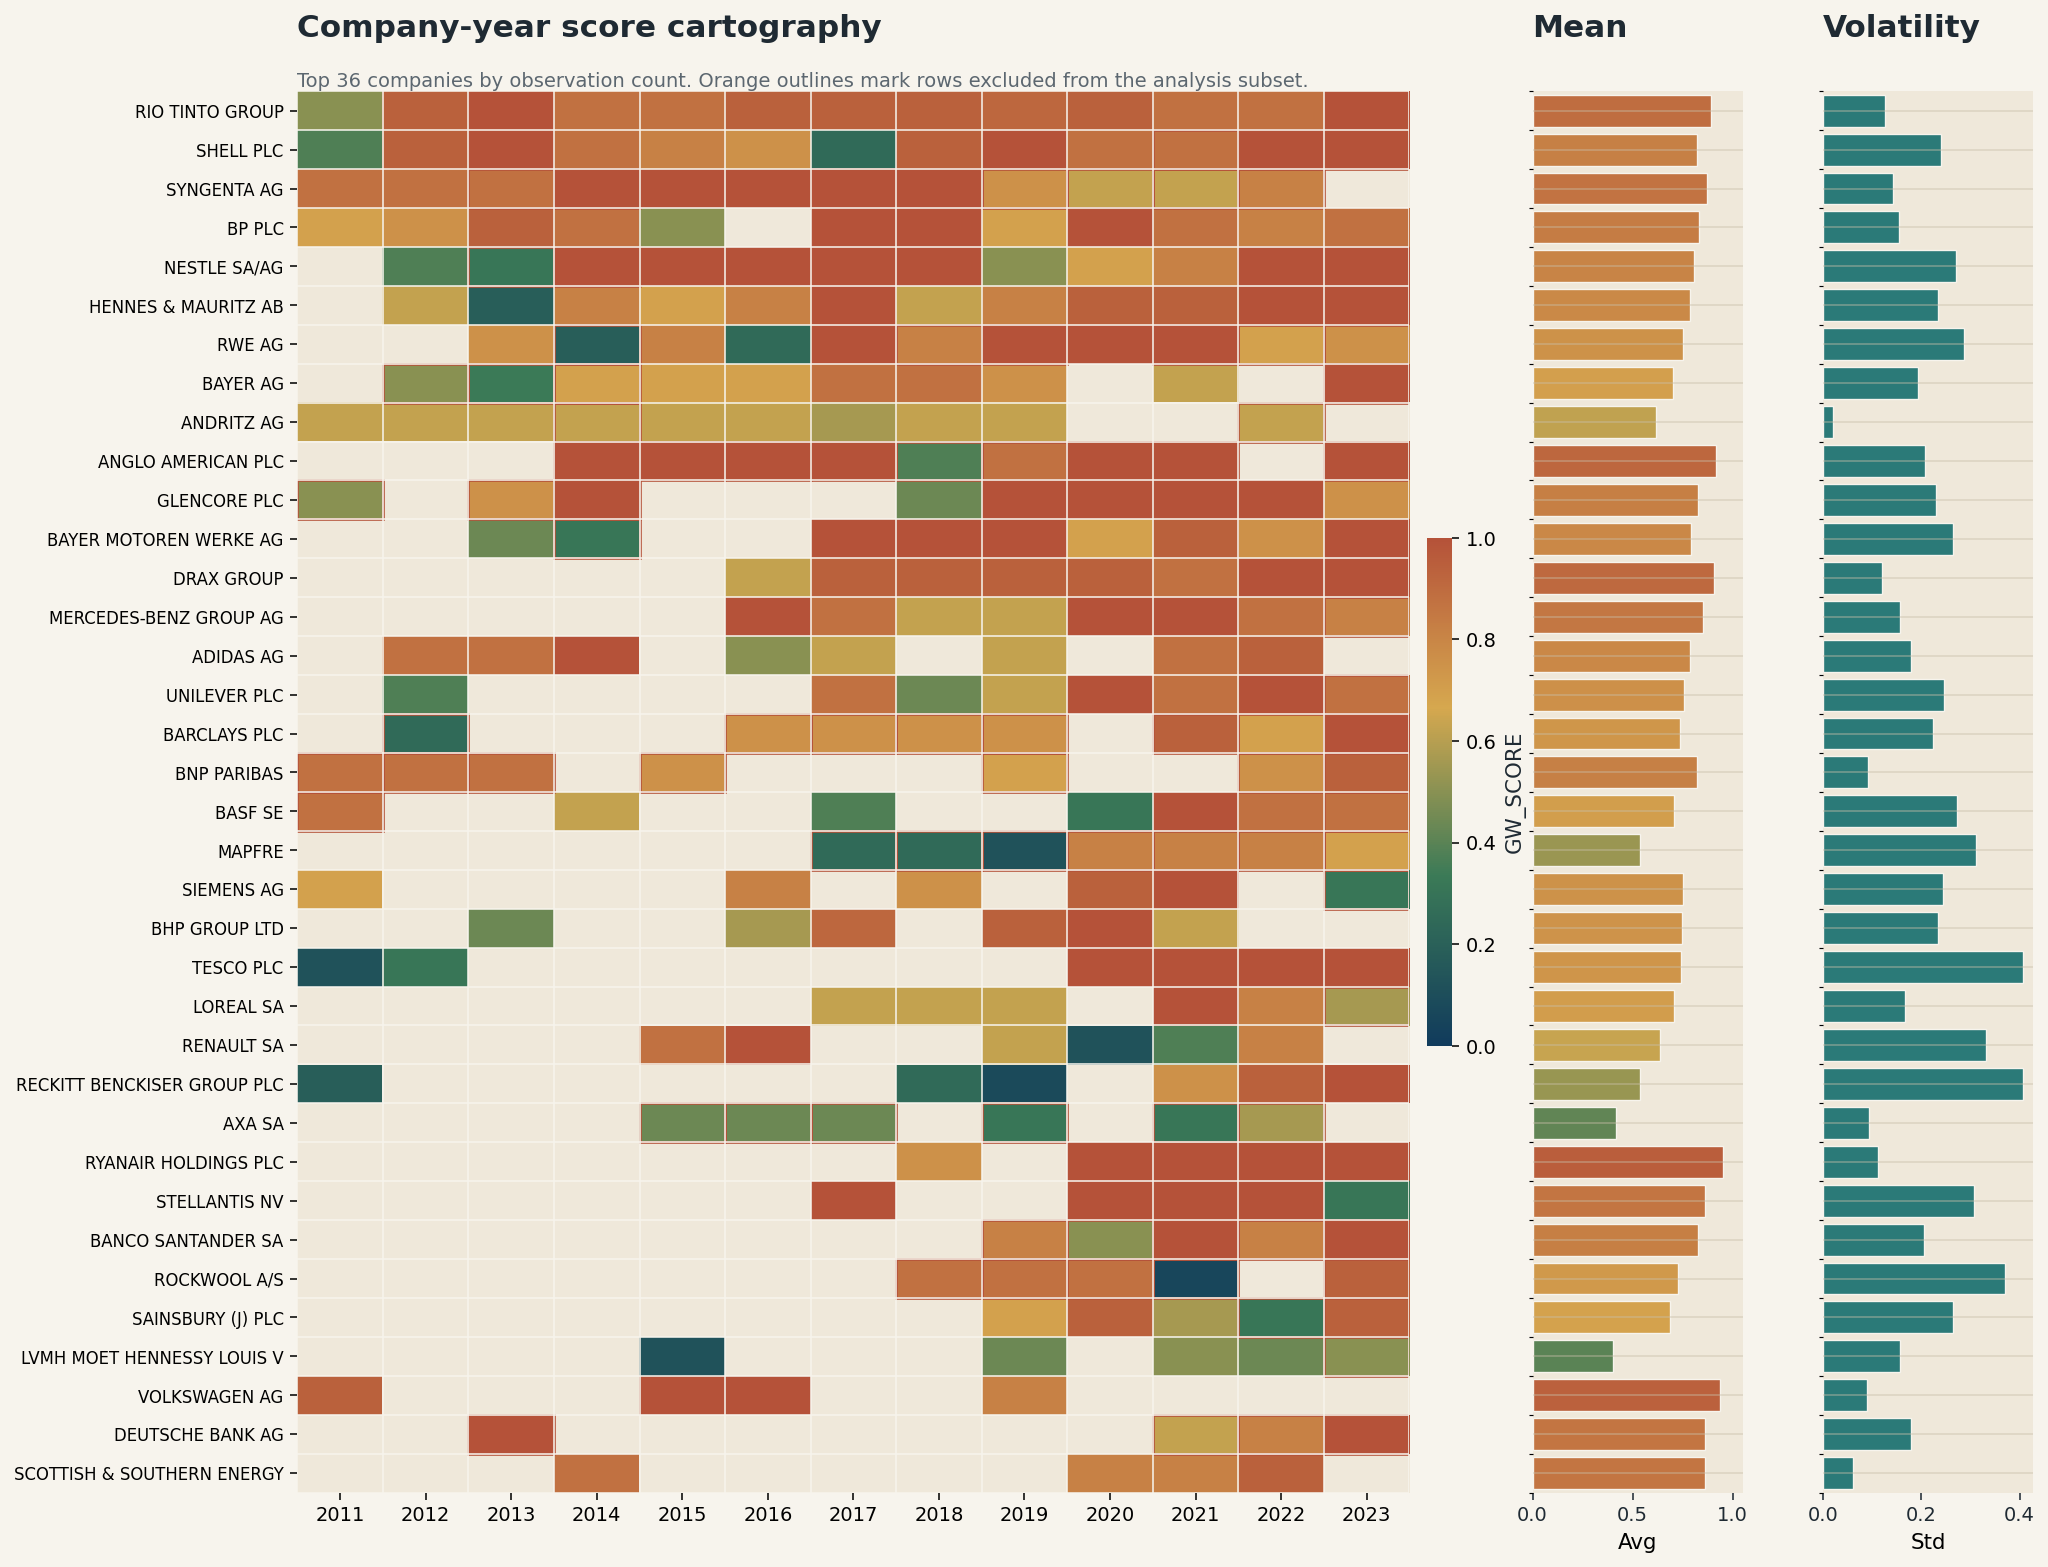

In [5]:
focus_companies = (
    company_features.sort_values(["observations", "mean_score"], ascending=[False, False])
    .head(36)
    .index
)

score_grid = (
    df[df["COMPANY_NAME"].isin(focus_companies)]
    .pivot(index="COMPANY_NAME", columns="YEAR", values="GW_SCORE")
    .reindex(index=focus_companies, columns=years)
)
used_grid = (
    df[df["COMPANY_NAME"].isin(focus_companies)]
    .pivot(index="COMPANY_NAME", columns="YEAR", values="USED_FOR_ANALYSIS")
    .reindex(index=focus_companies, columns=years)
)

fig = plt.figure(figsize=(16, 13), facecolor=PALETTE["paper"])
gs = GridSpec(1, 24, figure=fig, wspace=0.12)

ax = fig.add_subplot(gs[:, :16])
ax_mean = fig.add_subplot(gs[:, 17:20], sharey=ax)
ax_vol = fig.add_subplot(gs[:, 21:24], sharey=ax)

heat = ax.imshow(np.ma.masked_invalid(score_grid.to_numpy()), aspect="auto", cmap=SCORE_CMAP, vmin=0, vmax=1)
ax.set_facecolor(PALETTE["panel"])
ax.set_title(
    "Company-year score cartography",
    loc="left",
    fontsize=16,
    fontweight="bold",
    color=PALETTE["ink"],
    pad=28,
)
ax.text(
    0.0,
    1.0,
    "Top 36 companies by observation count. Orange outlines mark rows excluded from the analysis subset.",
    transform=ax.transAxes,
    fontsize=10,
    color=PALETTE["muted"],
    va="bottom",
    ha="left",
)
ax.set_xticks(np.arange(len(years)))
ax.set_xticklabels(years)
ax.set_yticks(np.arange(len(focus_companies)))
ax.set_yticklabels([name[:30] for name in focus_companies], fontsize=8.5)
ax.set_xticks(np.arange(-0.5, len(years), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(focus_companies), 1), minor=True)
ax.grid(which="minor", color=PALETTE["paper"], linewidth=0.8)
ax.tick_params(which="minor", bottom=False, left=False)
for spine in ax.spines.values():
    spine.set_visible(False)

for i in range(score_grid.shape[0]):
    for j in range(score_grid.shape[1]):
        flag = used_grid.iat[i, j]
        if pd.notna(flag) and (not bool(flag)):
            ax.add_patch(
                Rectangle(
                    (j - 0.5, i - 0.5),
                    1,
                    1,
                    fill=False,
                    edgecolor=PALETTE["accent"],
                    linewidth=1.35,
                )
            )

cbar = fig.colorbar(heat, ax=ax, fraction=0.022, pad=0.015)
cbar.set_label("GW_SCORE", color=PALETTE["ink"])
cbar.outline.set_visible(False)

mean_values = company_features.loc[focus_companies, "mean_score"].to_numpy()
style_axes(ax_mean, "Mean", None)
ax_mean.barh(
    np.arange(len(focus_companies)),
    mean_values,
    color=SCORE_CMAP(mean_values),
    height=0.82,
    edgecolor=PALETTE["paper"],
    linewidth=0.7,
)
ax_mean.set_xlim(0, 1.05)
ax_mean.set_xlabel("Avg")
ax_mean.tick_params(axis="y", left=False, labelleft=False)

vol_values = company_features.loc[focus_companies, "score_volatility"].to_numpy()
style_axes(ax_vol, "Volatility", None)
ax_vol.barh(
    np.arange(len(focus_companies)),
    vol_values,
    color=PALETTE["accent2"],
    height=0.82,
    edgecolor=PALETTE["paper"],
    linewidth=0.7,
)
ax_vol.set_xlabel("Std")
ax_vol.tick_params(axis="y", left=False, labelleft=False)

plt.show()

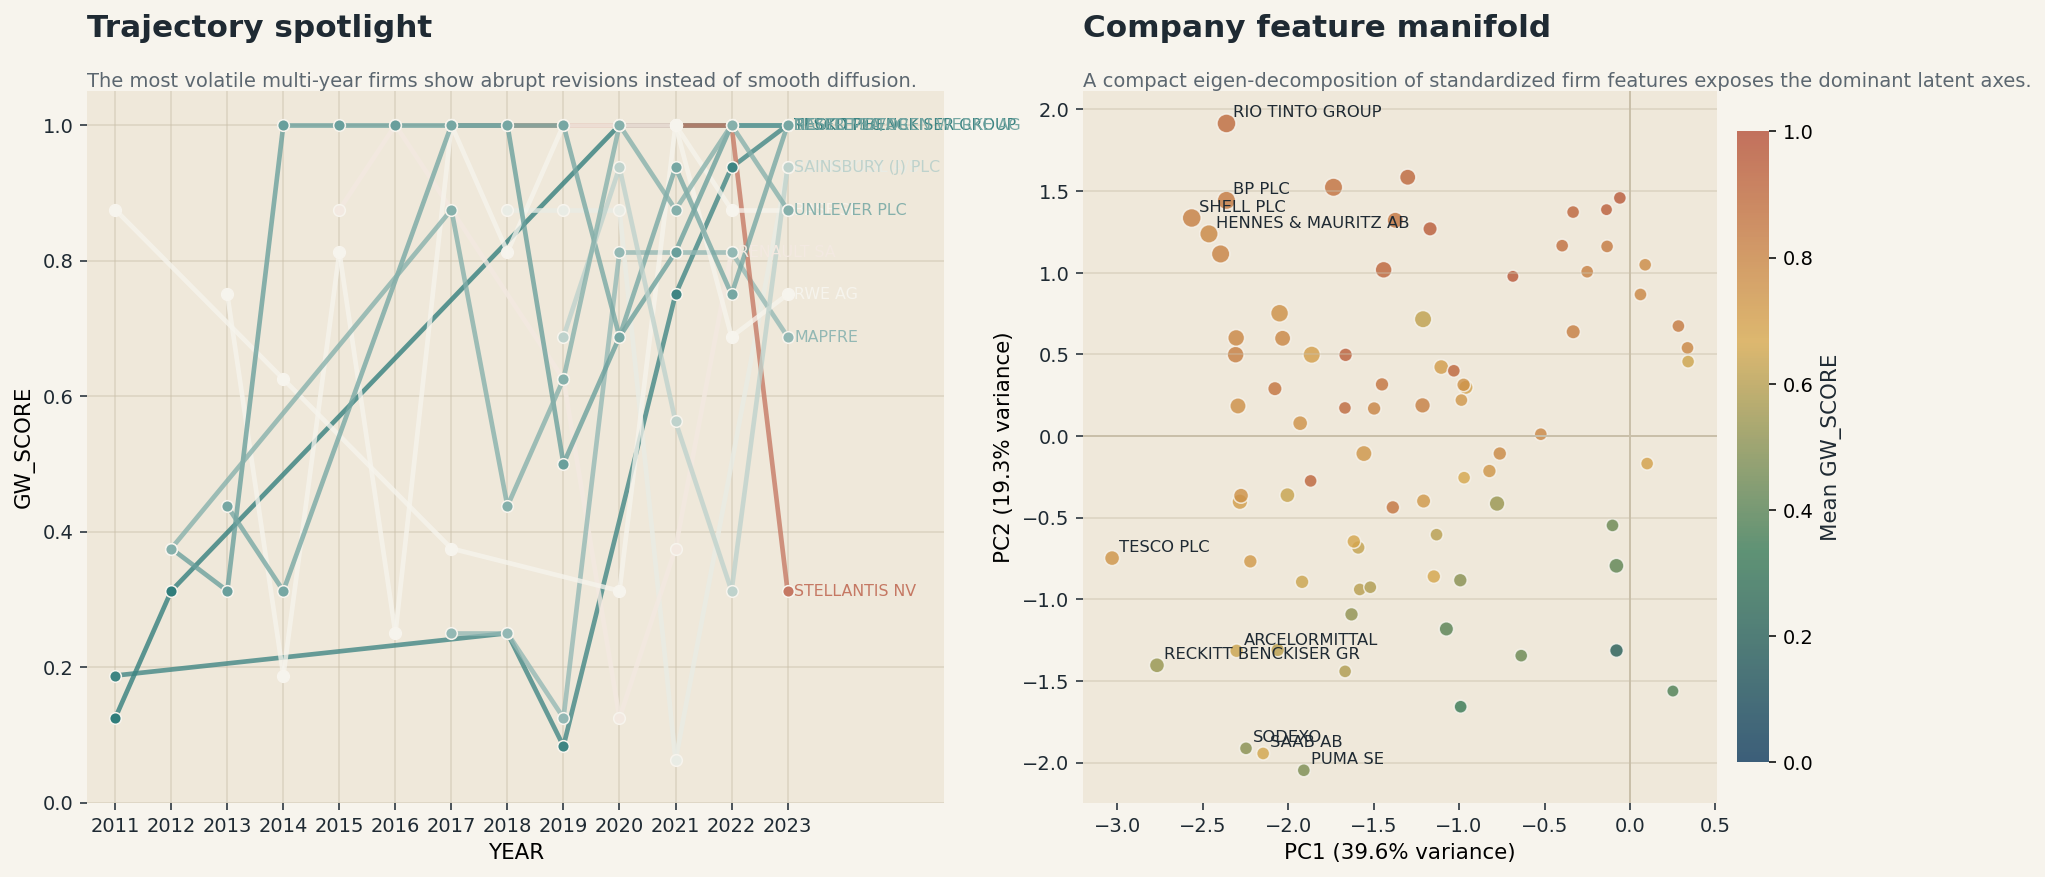

,Feature,PC1_loading,PC2_loading
1,score_volatility,-0.556,-0.343
2,observations,-0.509,0.182
3,window_density,0.476,0.430
4,used_share,-0.321,0.142
0,mean_score,-0.320,0.803


In [6]:
feature_cols = ["mean_score", "score_volatility", "observations", "window_density", "used_share"]
Z = (company_features[feature_cols] - company_features[feature_cols].mean()) / company_features[feature_cols].std(ddof=0)

Sigma = np.cov(Z.to_numpy(), rowvar=False)
eigvals, eigvecs = np.linalg.eigh(Sigma)
order = np.argsort(eigvals)[::-1]
eigvals = eigvals[order]
eigvecs = eigvecs[:, order]
variance_share = eigvals / eigvals.sum()

projection = pd.DataFrame(
    Z.to_numpy() @ eigvecs[:, :2],
    index=company_features.index,
    columns=["PC1", "PC2"],
).join(company_features[["observations", "mean_score", "score_volatility"]])

trajectory_names = (
    company_features.loc[company_features["observations"] >= 5]
    .sort_values(["score_volatility", "observations"], ascending=[False, False])
    .head(12)
    .index
)

fig = plt.figure(figsize=(15.5, 6.6), facecolor=PALETTE["paper"])
gs = GridSpec(1, 2, figure=fig, width_ratios=[1.25, 1.0], wspace=0.18)

ax = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

style_axes(
    ax,
    "Trajectory spotlight",
    "The most volatile multi-year firms show abrupt revisions instead of smooth diffusion.",
)
ax.grid(axis="x", color=PALETTE["grid"], linewidth=0.9, alpha=0.45)
for name in trajectory_names:
    sub = df.loc[df["COMPANY_NAME"] == name].sort_values("YEAR")
    x = sub["YEAR"].to_numpy()
    y = sub["GW_SCORE"].to_numpy()
    delta = y[-1] - y[0]
    color = DELTA_CMAP(DELTA_NORM(delta))
    points = np.column_stack([x, y]).reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    ax.add_collection(LineCollection(segments, colors=[color] * len(segments), linewidths=2.4, alpha=0.78))
    ax.scatter(x, y, s=36, color=color, edgecolor=PALETTE["paper"], linewidth=0.8, zorder=3)
    ax.text(x[-1] + 0.12, y[-1], name[:24], fontsize=8.2, color=color, va="center")

ax.set_xlim(years.min() - 0.5, years.max() + 2.8)
ax.set_ylim(0, 1.05)
ax.set_xticks(years)
ax.set_ylabel("GW_SCORE")
ax.set_xlabel("YEAR")

style_axes(
    ax2,
    "Company feature manifold",
    "A compact eigen-decomposition of standardized firm features exposes the dominant latent axes.",
)
ax2.axhline(0, color=PALETTE["grid"], linewidth=1.0)
ax2.axvline(0, color=PALETTE["grid"], linewidth=1.0)

focus_projection = projection.sort_values("observations", ascending=False).head(80)
scatter = ax2.scatter(
    focus_projection["PC1"],
    focus_projection["PC2"],
    s=30 + focus_projection["observations"] * 5,
    c=focus_projection["mean_score"],
    cmap=SCORE_CMAP,
    vmin=0,
    vmax=1,
    alpha=0.82,
    edgecolor=PALETTE["paper"],
    linewidth=0.8,
)

label_candidates = (
    focus_projection.assign(radius=lambda d: np.hypot(d["PC1"], d["PC2"]))
    .sort_values("radius", ascending=False)
    .head(10)
)
for name, row in label_candidates.iterrows():
    ax2.text(row["PC1"] + 0.04, row["PC2"] + 0.04, name[:20], fontsize=8.4, color=PALETTE["ink"])

ax2.set_xlabel(f"PC1 ({variance_share[0]:.1%} variance)")
ax2.set_ylabel(f"PC2 ({variance_share[1]:.1%} variance)")

cbar = fig.colorbar(scatter, ax=ax2, fraction=0.046, pad=0.03)
cbar.set_label("Mean GW_SCORE", color=PALETTE["ink"])
cbar.outline.set_visible(False)

plt.show()

loadings = pd.DataFrame(
    {
        "Feature": feature_cols,
        "PC1_loading": eigvecs[:, 0],
        "PC2_loading": eigvecs[:, 1],
    }
).sort_values("PC1_loading", key=np.abs, ascending=False)

display(loadings.style.format({"PC1_loading": "{:.3f}", "PC2_loading": "{:.3f}"}))

## Findings

1. The dataset is a sparse panel: 595 rows span 215 companies across 13 years, so only about one fifth of the company by year grid is populated.
2. The score process is discretized. There are only 22 distinct score states, and the empirical entropy is much lower than a continuous view would suggest.
3. Coverage is highly imbalanced. A large fraction of companies appear only once, while a small set of long-history firms dominates multi-year pattern recognition.
4. The 2023 slice behaves differently: it has substantial coverage, but the share marked `USED_FOR_ANALYSIS=True` drops sharply, which suggests a deliberate holdout or post-hoc exclusion boundary.
5. The company-level eigenspace is useful for downstream modeling because it separates firms by persistence, score level, and volatility without requiring any label engineering.